# Importing Libraries

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder,StandardScaler,PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

In [15]:
df = pd.read_csv('Housing.csv')
df.head(2)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished


In [16]:
X = df.drop('price',axis=1)
y = df['price']
print(X.head(2))
print(y.head(2))

   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  7420         4          2        3      yes        no       no   
1  8960         4          4        4      yes        no       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
0    13300000
1    12250000
Name: price, dtype: int64


Y

# 

In [17]:
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
X[binary_cols] = X[binary_cols].replace({
    'yes':1,'no':0
})
X.head(2)

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,8960,4,4,4,1,0,0,0,1,3,0,furnished


# Encoding Catagorical column

In [18]:
encoder = OneHotEncoder(drop='first',sparse_output=False)
encoded = encoder.fit_transform(X[['furnishingstatus']])
encoded_df = pd.DataFrame(encoded,columns=encoder.get_feature_names_out(['furnishingstatus']),index=X.index)

X = X.drop('furnishingstatus',axis=1)
X = pd.concat([X,encoded_df],axis=1)
X.head(2)


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,0.0,0.0
1,8960,4,4,4,1,0,0,0,1,3,0,0.0,0.0


# Spliting Data

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Polynomial Features

In [ ]:
numeric_cols = ['area','bedrooms','bathrooms','stories','parking']

polynomial = PolynomialFeatures(degree=2,include_bias=False)

X_train_poly_part = polynomial.fit_transform(X_train[numeric_cols])
X_test_poly_part = polynomial.transform(X_test[numeric_cols])

X_train_poly_df = pd.DataFrame(
    X_train_poly_part,
    columns=polynomial.get_feature_names_out(numeric_cols),
    index=X_train.index   
)

X_test_poly_df = pd.DataFrame(
    X_test_poly_part,
    columns=polynomial.get_feature_names_out(numeric_cols),
    index=X_test.index   
)

X_train_rem = X_train.drop(numeric_cols,axis=1)
X_test_rem = X_test.drop(numeric_cols,axis=1)

X_train_final = pd.concat([X_train_rem,X_train_poly_df],axis=1)
X_test_final = pd.concat([X_test_rem,X_test_poly_df],axis=1)

X_train_final.head(2)

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,area,bedrooms,...,bedrooms^2,bedrooms bathrooms,bedrooms stories,bedrooms parking,bathrooms^2,bathrooms stories,bathrooms parking,stories^2,stories parking,parking^2
46,1,0,0,0,1,0,0.0,0.0,6000.0,3.0,...,9.0,6.0,12.0,3.0,4.0,8.0,2.0,16.0,4.0,1.0
93,1,0,1,0,1,0,1.0,0.0,7200.0,3.0,...,9.0,6.0,3.0,9.0,4.0,2.0,6.0,1.0,3.0,9.0


# Scaling

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)


# Training Model

In [25]:
model = LinearRegression()

model.fit(X_train_scaled,y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Prediction

In [26]:
y_pred = model.predict(X_test_scaled)

# Ploting Actual vs Predicted

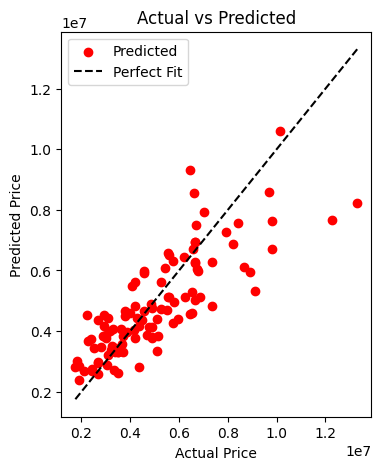

In [29]:
plt.figure(figsize=(4,5))
plt.scatter(y_test,y_pred,color='red',label='Predicted')
plt.plot([y.min(),y.max()],[y.min(),y.max()],'k--',label='Perfect Fit')
plt.title("Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")   
plt.legend()
plt.show()

# MSE and R2

In [32]:
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print(f'Mean Squared Error : {mse:.3f}')
print(f'R2 Score : {r2:.3f}')

Mean Squared Error : 1771055454643.679
R2 Score : 0.650


# R2 score explicitly

In [33]:
print('Train R2 : ',model.score(X_train_scaled,y_train))
print('Test R2 : ',model.score(X_test_scaled,y_test))

Train R2 :  0.7163746790755061
Test R2 :  0.6496130495131252
